In [1]:
# 1. Import Libraries

import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
# 2. Load Breast Cancer Dataset

data = load_breast_cancer()

X = data.data      # input features
y = data.target    # target labels

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Target names:", data.target_names)

X shape: (569, 30)
y shape: (569,)
Target names: ['malignant' 'benign']


In [3]:
# 3. Split Data into Train, Validation, and Test

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (341, 30)
Validation shape: (114, 30)
Test shape: (114, 30)


In [4]:
# 4. Standard Scaling

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [5]:
# 5. Convert Data to PyTorch Tensors

X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train).view(-1, 1)

X_val = torch.FloatTensor(X_val)
y_val = torch.FloatTensor(y_val).view(-1, 1)

X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test).view(-1, 1)

In [6]:
# 6. Build MLP Model - Experiment 1

model = nn.Sequential(
    nn.Linear(30, 32),   # Input layer to hidden layer
    nn.ReLU(),           # Activation function

    nn.Linear(32, 16),   # Hidden layer
    nn.ReLU(),           # Activation function

    nn.Linear(16, 1),    # Output layer
    nn.Sigmoid()         # Output between 0 and 1
)

print(model)

Sequential(
  (0): Linear(in_features=30, out_features=32, bias=True)
  (1): ReLU()
  (2): Linear(in_features=32, out_features=16, bias=True)
  (3): ReLU()
  (4): Linear(in_features=16, out_features=1, bias=True)
  (5): Sigmoid()
)


In [7]:
# 7. Optimizer and Loss Function

optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.BCELoss()

In [8]:
# 8. Training Loop

epochs = 100

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

for epoch in range(epochs):

    # Training mode
    model.train()

    # Forward pass
    train_outputs = model(X_train)
    train_loss = criterion(train_outputs, y_train)

    # Backward pass
    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    # Calculate training accuracy
    train_preds = (train_outputs > 0.5).float()
    train_acc = (train_preds == y_train).float().mean()

    # Validation mode
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, y_val)

        val_preds = (val_outputs > 0.5).float()
        val_acc = (val_preds == y_val).float().mean()

    # Store values
    train_losses.append(train_loss.item())
    val_losses.append(val_loss.item())

    train_accuracies.append(train_acc.item())
    val_accuracies.append(val_acc.item())

    # Print progress
    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss.item():.4f} | "
            f"Val Loss: {val_loss.item():.4f} | "
            f"Train Acc: {train_acc.item():.4f} | "
            f"Val Acc: {val_acc.item():.4f}"
        )

Epoch 10/100 | Train Loss: 0.1948 | Val Loss: 0.1868 | Train Acc: 0.9560 | Val Acc: 0.9386
Epoch 20/100 | Train Loss: 0.0485 | Val Loss: 0.1560 | Train Acc: 0.9853 | Val Acc: 0.9649
Epoch 30/100 | Train Loss: 0.0219 | Val Loss: 0.1941 | Train Acc: 0.9912 | Val Acc: 0.9649
Epoch 40/100 | Train Loss: 0.0110 | Val Loss: 0.2002 | Train Acc: 0.9971 | Val Acc: 0.9649
Epoch 50/100 | Train Loss: 0.0053 | Val Loss: 0.2080 | Train Acc: 1.0000 | Val Acc: 0.9649
Epoch 60/100 | Train Loss: 0.0025 | Val Loss: 0.2219 | Train Acc: 1.0000 | Val Acc: 0.9649
Epoch 70/100 | Train Loss: 0.0014 | Val Loss: 0.9577 | Train Acc: 1.0000 | Val Acc: 0.9649
Epoch 80/100 | Train Loss: 0.0009 | Val Loss: 0.9571 | Train Acc: 1.0000 | Val Acc: 0.9649
Epoch 90/100 | Train Loss: 0.0006 | Val Loss: 0.9584 | Train Acc: 1.0000 | Val Acc: 0.9649
Epoch 100/100 | Train Loss: 0.0005 | Val Loss: 0.9606 | Train Acc: 1.0000 | Val Acc: 0.9649


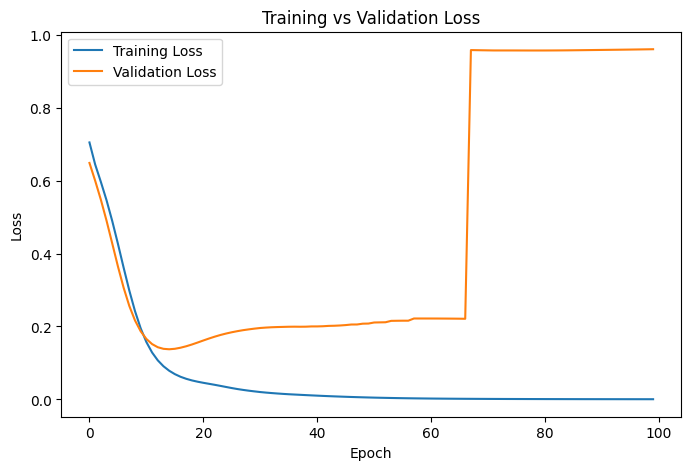

In [9]:
# 9. Plot Training and Validation Loss

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

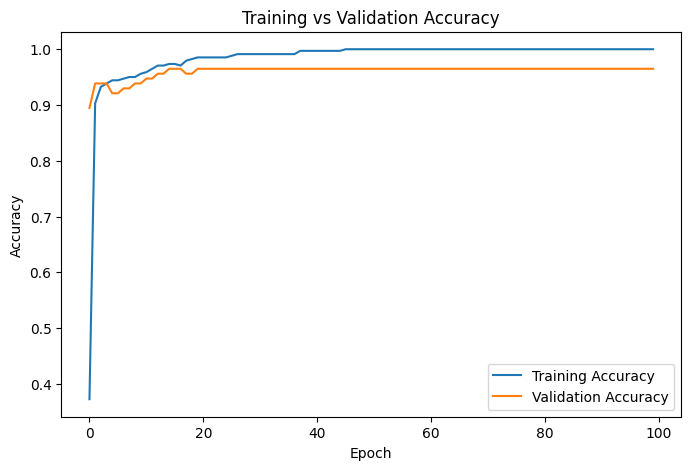

In [10]:
# 10. Plot Training and Validation Accuracy

plt.figure(figsize=(8, 5))
plt.plot(train_accuracies, label="Training Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

In [11]:
# 11. Evaluate Model on Test Data

model.eval()

with torch.no_grad():
    test_outputs = model(X_test)
    test_loss = criterion(test_outputs, y_test)

    test_preds = (test_outputs > 0.5).float()
    test_accuracy = (test_preds == y_test).float().mean()

print("Final Test Loss:", test_loss.item())
print("Test Accuracy:", test_accuracy.item())

Final Test Loss: 0.1805814951658249
Test Accuracy: 0.9649122953414917


In [12]:
# 12. Experiment 2 - Different Architecture

model2 = nn.Sequential(
    nn.Linear(30, 64),
    nn.Tanh(),

    nn.Linear(64, 32),
    nn.Tanh(),

    nn.Linear(32, 1),
    nn.Sigmoid()
)

optimizer2 = optim.Adam(model2.parameters(), lr=0.001)
criterion2 = nn.BCELoss()

epochs = 100

train_losses2 = []
val_losses2 = []

train_accuracies2 = []
val_accuracies2 = []

for epoch in range(epochs):

    # Training
    model2.train()

    train_outputs2 = model2(X_train)
    train_loss2 = criterion2(train_outputs2, y_train)

    optimizer2.zero_grad()
    train_loss2.backward()
    optimizer2.step()

    train_preds2 = (train_outputs2 > 0.5).float()
    train_acc2 = (train_preds2 == y_train).float().mean()

    # Validation
    model2.eval()
    with torch.no_grad():
        val_outputs2 = model2(X_val)
        val_loss2 = criterion2(val_outputs2, y_val)

        val_preds2 = (val_outputs2 > 0.5).float()
        val_acc2 = (val_preds2 == y_val).float().mean()

    train_losses2.append(train_loss2.item())
    val_losses2.append(val_loss2.item())

    train_accuracies2.append(train_acc2.item())
    val_accuracies2.append(val_acc2.item())

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss2.item():.4f} | "
            f"Val Loss: {val_loss2.item():.4f} | "
            f"Train Acc: {train_acc2.item():.4f} | "
            f"Val Acc: {val_acc2.item():.4f}"
        )

Epoch 10/100 | Train Loss: 0.4584 | Val Loss: 0.4553 | Train Acc: 0.9003 | Val Acc: 0.9123
Epoch 20/100 | Train Loss: 0.3046 | Val Loss: 0.3144 | Train Acc: 0.9150 | Val Acc: 0.9123
Epoch 30/100 | Train Loss: 0.2085 | Val Loss: 0.2293 | Train Acc: 0.9355 | Val Acc: 0.9211
Epoch 40/100 | Train Loss: 0.1479 | Val Loss: 0.1762 | Train Acc: 0.9589 | Val Acc: 0.9386
Epoch 50/100 | Train Loss: 0.1097 | Val Loss: 0.1432 | Train Acc: 0.9707 | Val Acc: 0.9561
Epoch 60/100 | Train Loss: 0.0854 | Val Loss: 0.1263 | Train Acc: 0.9765 | Val Acc: 0.9649
Epoch 70/100 | Train Loss: 0.0695 | Val Loss: 0.1189 | Train Acc: 0.9853 | Val Acc: 0.9649
Epoch 80/100 | Train Loss: 0.0587 | Val Loss: 0.1156 | Train Acc: 0.9912 | Val Acc: 0.9649
Epoch 90/100 | Train Loss: 0.0510 | Val Loss: 0.1139 | Train Acc: 0.9912 | Val Acc: 0.9649
Epoch 100/100 | Train Loss: 0.0452 | Val Loss: 0.1127 | Train Acc: 0.9912 | Val Acc: 0.9649


In [13]:
# 13. Evaluate Experiment 2 on Test Data

model2.eval()

with torch.no_grad():
    test_outputs2 = model2(X_test)
    test_loss2 = criterion2(test_outputs2, y_test)

    test_preds2 = (test_outputs2 > 0.5).float()
    test_accuracy2 = (test_preds2 == y_test).float().mean()

print("Experiment 2 Final Test Loss:", test_loss2.item())
print("Experiment 2 Test Accuracy:", test_accuracy2.item())

Experiment 2 Final Test Loss: 0.0642249584197998
Experiment 2 Test Accuracy: 0.9824561476707458


In [14]:
# 14. Compare Results

print("Experiment 1")
print("Activation Function: ReLU")
print("Hidden Neurons: 32, 16")
print("Learning Rate: 0.01")
print("Final Test Loss:", test_loss.item())
print("Test Accuracy:", test_accuracy.item())

print("\nExperiment 2")
print("Activation Function: Tanh")
print("Hidden Neurons: 64, 32")
print("Learning Rate: 0.001")
print("Final Test Loss:", test_loss2.item())
print("Test Accuracy:", test_accuracy2.item())

Experiment 1
Activation Function: ReLU
Hidden Neurons: 32, 16
Learning Rate: 0.01
Final Test Loss: 0.1805814951658249
Test Accuracy: 0.9649122953414917

Experiment 2
Activation Function: Tanh
Hidden Neurons: 64, 32
Learning Rate: 0.001
Final Test Loss: 0.0642249584197998
Test Accuracy: 0.9824561476707458


In [15]:
# 15. Results Table

import pandas as pd

results = {
    "Experiment": ["Experiment 1", "Experiment 2"],
    "Activation Function": ["ReLU", "Tanh"],
    "Hidden Neurons": ["32, 16", "64, 32"],
    "Learning Rate": [0.01, 0.001],
    "Final Test Loss": [test_loss.item(), test_loss2.item()],
    "Test Accuracy": [test_accuracy.item(), test_accuracy2.item()]
}

results_df = pd.DataFrame(results)
print(results_df)

     Experiment Activation Function Hidden Neurons  Learning Rate  \
0  Experiment 1                ReLU         32, 16          0.010   
1  Experiment 2                Tanh         64, 32          0.001   

   Final Test Loss  Test Accuracy  
0         0.180581       0.964912  
1         0.064225       0.982456  


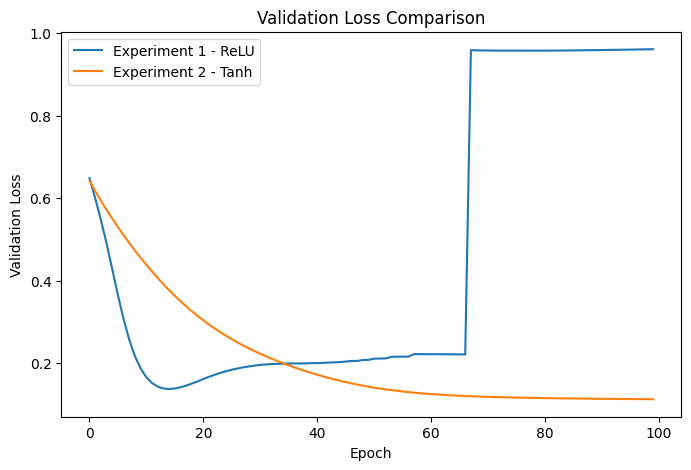

In [16]:
# 16. Compare Validation Loss of Both Experiments

plt.figure(figsize=(8, 5))
plt.plot(val_losses, label="Experiment 1 - ReLU")
plt.plot(val_losses2, label="Experiment 2 - Tanh")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison")
plt.legend()
plt.show()

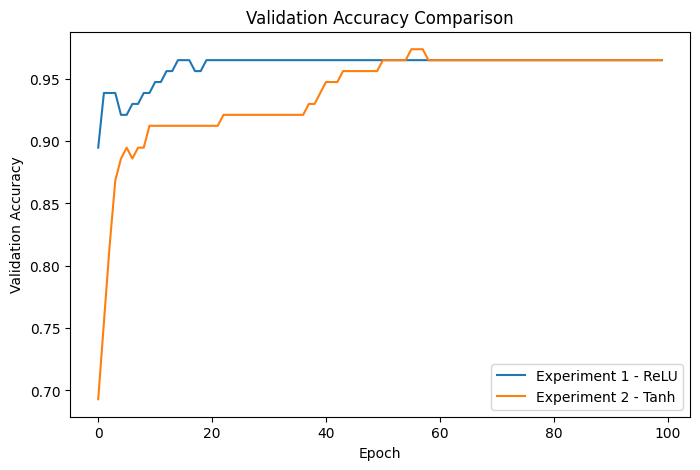

In [17]:
# 17. Compare Validation Accuracy of Both Experiments

plt.figure(figsize=(8, 5))
plt.plot(val_accuracies, label="Experiment 1 - ReLU")
plt.plot(val_accuracies2, label="Experiment 2 - Tanh")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison")
plt.legend()
plt.show()